# Stroke Prediction Analysis

This notebook implements a complete data science workflow for stroke prediction, addressing class imbalance and comparing multiple models including Random Forest, Logistic Regression, XGBoost, and a Neural Network.

In [188]:
## 1. Imports and Setup

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import xgboost as xgb

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, 
    precision_score, recall_score, f1_score, precision_recall_curve
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer
from sklearn.feature_selection import VarianceThreshold

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier

# Set random seed
np.random.seed(42)
torch.manual_seed(42)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print(f"PyTorch Device: {'mps' if torch.backends.mps.is_available() else 'cpu'}")

# Helper functions for EDA plotting

def plot_categorical_rates(df, cat_vars, figsize=(18, 18)):
    """
    Plot stroke rates for categorical variables in a grid layout.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    n_vars = len(cat_vars)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for i, var in enumerate(cat_vars):
        ax = axes[i]
        stroke_rates = df.groupby(var)["stroke"].mean().reset_index()
        counts = df.groupby(var)["stroke"].count().reset_index()
        stroke_rates['count'] = counts['stroke']
        sns.barplot(data=stroke_rates, x=var, y="stroke", hue=var, ax=ax, legend=False)
        ax.set_title(f"Stroke Rate by {var.replace('_', ' ').title()}")
        ax.set_ylabel("Stroke Rate")
        ax.set_xlabel("")

        for p, count in zip(ax.patches, stroke_rates['count']):
            ax.annotate(f"{p.get_height():.3f}\n(n={count})", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    # Hide unused subplots
    for j in range(len(cat_vars), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_numerical_stroke_rates(df, num_vars, bin_dict, figsize=(18, 6)):
    """
    Plot stroke rates for numerical variables by bins.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    fig, axes = plt.subplots(1, len(num_vars), figsize=figsize)

    for i, var in enumerate(num_vars):
        bins = bin_dict[var]
        df[f'{var}_bin'] = pd.cut(df[var], bins=bins)
        bin_stats = df.groupby(f'{var}_bin', observed=False)['stroke'].agg(['mean', 'count']).reset_index()
        bin_stats['label'] = bin_stats[f'{var}_bin'].apply(lambda x: f'{x.left:.1f}-{x.right:.1f}' if x.right < 100 else f'{x.left:.1f}+')

        sns.barplot(data=bin_stats, x='label', y='mean', hue='label', ax=axes[i], legend=False)
        for bar, count in zip(axes[i].patches, bin_stats['count']):
            axes[i].annotate(f'{bar.get_height():.3f}\n(n={count})', (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha='center', va='bottom', fontsize=8)

        axes[i].set_title(f'Stroke Rate by {var.replace("_", " ").title()}')
        axes[i].set_xlabel(var.replace("_", " ").title())
        axes[i].set_ylabel('Stroke Rate')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


def plot_binned_ratios(df, num_vars, bin_dict, figsize=(18, 6)):
    """
    Plot strokes/non-strokes ratios by binned numerical variables.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    fig, axes = plt.subplots(1, len(num_vars), figsize=figsize)

    for i, var in enumerate(num_vars):
        bins = bin_dict[var]
        df[f'{var}_bin'] = pd.cut(df[var], bins=bins)
        bin_stats = df.groupby(f'{var}_bin', observed=False)['stroke'].agg(lambda x: (x.sum(), (1 - x).sum())).reset_index()
        bin_stats['ratio'] = bin_stats['stroke'].apply(lambda x: x[0] / x[1] if x[1] > 0 else 0)
        bin_stats['total_count'] = bin_stats['stroke'].apply(lambda x: x[0] + x[1])
        bin_stats['label'] = bin_stats[f'{var}_bin'].apply(lambda x: f'{x.left:.1f}-{x.right:.1f}' if x.right < 100 else f'{x.left:.1f}+')

        sns.barplot(data=bin_stats, x='label', y='ratio', ax=axes[i])
        for bar, count in zip(axes[i].patches, bin_stats['total_count']):
            axes[i].annotate(f'{bar.get_height():.3f}\n(n={int(count)})', (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha='center', va='bottom', fontsize=8)

        axes[i].set_title(f'Strokes / Non-Strokes Ratio by {var.replace("_", " ").title()}')
        axes[i].set_xlabel(var.replace("_", " ").title())
        axes[i].set_ylabel('Strokes / Non-Strokes')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


def plot_categorical_rates_by_gender(df, cat_vars, figsize=(18, 12)):
    """
    Plot stroke rates for categorical variables broken down by gender.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    n_vars = len(cat_vars)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, var in enumerate(cat_vars):
        ax = axes[i]
        stroke_rates = df.groupby([var, "gender"])["stroke"].mean().reset_index()
        counts = df.groupby([var, "gender"])["stroke"].count().reset_index()
        stroke_rates['count'] = counts['stroke']
        # Map gender for legend
        stroke_rates['gender_label'] = stroke_rates['gender'].map({1: 'Male', 0: 'Female'})
        sns.barplot(data=stroke_rates, x=var, y="stroke", hue="gender_label", ax=ax, palette="viridis")
        ax.set_title(f"Stroke Rate by {var.replace('_', ' ').title()} and Gender")
        ax.set_ylabel("Stroke Rate")
        ax.set_xlabel("")
        ax.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')

        for p, count in zip(ax.patches, stroke_rates['count']):
            ax.annotate(f"{p.get_height():.3f}\n(n={count})", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    # Hide unused subplots
    for j in range(len(cat_vars), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_numerical_stroke_rates_by_gender(df, num_vars, bin_dict, figsize=(12, 18)):
    """
    Plot stroke rates for numerical variables by bins, by gender.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    fig, axes = plt.subplots(len(num_vars), 2, figsize=figsize)

    for i, var in enumerate(num_vars):
        for j, gender_val in enumerate([1, 0]):  # 1=Male, 0=Female
            gender_label = 'Male' if gender_val == 1 else 'Female'
            ax = axes[i, j]
            subset = df[df['gender'] == gender_val].copy()
            subset[f'{var}_bin'] = pd.cut(subset[var], bins=bin_dict[var])
            bin_stats = subset.groupby(f'{var}_bin', observed=False)['stroke'].agg(['mean', 'count']).reset_index()
            bin_stats['label'] = bin_stats[f'{var}_bin'].apply(lambda x: f'{x.left:.1f}-{x.right:.1f}' if x.right < 100 else f'{x.left:.1f}+')

            sns.barplot(data=bin_stats, x='label', y='mean', hue='label', ax=ax, legend=False)
            for bar, count in zip(ax.patches, bin_stats['count']):
                ax.annotate(f'{bar.get_height():.3f}\n(n={count})', (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha='center', va='bottom', fontsize=8)

            ax.set_title(f'{var.replace("_", " ").title()} - {gender_label}')
            ax.set_xlabel(var.replace("_", " ").title())
            ax.set_ylabel('Stroke Rate')
            ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


def plot_binned_ratios_by_gender(df, num_vars, bin_dict, figsize=(12, 18)):
    """
    Plot strokes/non-strokes ratios by binned numerical variables, by gender.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    fig, axes = plt.subplots(len(num_vars), 2, figsize=figsize)

    for i, var in enumerate(num_vars):
        for j, gender_val in enumerate([1, 0]):  # 1=Male, 0=Female
            gender_label = 'Male' if gender_val == 1 else 'Female'
            ax = axes[i, j]
            subset = df[df['gender'] == gender_val].copy()
            subset[f'{var}_bin'] = pd.cut(subset[var], bins=bin_dict[var])
            bin_stats = subset.groupby(f'{var}_bin', observed=False)['stroke'].agg(lambda x: (x.sum(), (1 - x).sum())).reset_index()

            # Reindex to include empty bins
            all_bins = pd.cut([], bins=bin_dict[var]).categories
            all_bins.name = f'{var}_bin'
            bin_stats = bin_stats.set_index(f'{var}_bin').reindex(all_bins, fill_value={'stroke': (0, 0)}).reset_index()
            bin_stats['ratio'] = bin_stats['stroke'].apply(lambda x: x[0] / x[1] if x[1] > 0 else 0)
            bin_stats['total_count'] = bin_stats['stroke'].apply(lambda x: x[0] + x[1])
            bin_stats['label'] = bin_stats[f'{var}_bin'].apply(lambda x: f'{x.left:.1f}-{x.right:.1f}' if x.right < 100 else f'{x.left:.1f}+')

            sns.barplot(data=bin_stats, x='label', y='ratio', ax=ax)
            for bar, count in zip(ax.patches, bin_stats['total_count']):
                ax.annotate(f'{bar.get_height():.3f}\n(n={int(count)})', (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha='center', va='bottom', fontsize=8)

            ax.set_title(f'{var.replace("_", " ").title()} - {gender_label}')
            ax.set_xlabel(var.replace("_", " ").title())
            ax.set_ylabel('Strokes / Non-Strokes')
            ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


def plot_numerical_dist(df, num_vars, bin_dict, figsize=(18, 6)):
    """
    Alias for plot_numerical_stroke_rates.
    """
    plot_numerical_stroke_rates(df, num_vars, bin_dict, figsize)


PyTorch Device: mps


In [189]:
# ---------------------------------------------------------
# CORE LOGIC: Feature Engineering & Imputation
# ---------------------------------------------------------

import pandas as pd
import numpy as np

def create_composite_risk_features(stroke_df):
    """
    Calculate composite risk interaction features for stroke prediction.

    Parameters:
    stroke_df (pd.DataFrame): Input DataFrame containing stroke data with various columns depending on version.

    Returns:
    pd.DataFrame: Modified DataFrame with added composite risk features where required columns exist.
    """
    # Handle smoking status formats
    smoking_available = all(col in stroke_df.columns for col in ['smoking_current', 'smoking_former', 'smoking_never'])
    if not smoking_available and 'smoking_status' in stroke_df.columns:
        # Encode smoking_status into binary columns
        stroke_df['smoking_never'] = (stroke_df['smoking_status'] == 'never smoked').astype(int)
        stroke_df['smoking_former'] = (stroke_df['smoking_status'] == 'formerly smoked').astype(int)
        stroke_df['smoking_current'] = (stroke_df['smoking_status'] == 'smokes').astype(int)
        smoking_available = True
        # Drop original smoking columns after encoding
        stroke_df = stroke_df.drop(['smoking_status', 'smoking_status_encoded'], axis=1, errors='ignore')

    # Create interaction features
    # Multiplicative interaction: BMI × Glucose
    required = ['bmi', 'avg_glucose_level']
    if all(col in stroke_df.columns for col in required):
        stroke_df['bmi_glucose_interaction'] = stroke_df['bmi'] * stroke_df['avg_glucose_level']
    else:
        raise ValueError(f"Required columns {required} not found for bmi_glucose_interaction")

    # Multiplicative interaction: BMI × Age
    required = ['bmi', 'age']
    if all(col in stroke_df.columns for col in required):
        stroke_df['bmi_age_interaction'] = stroke_df['bmi'] * stroke_df['age']
    else:
        raise ValueError(f"Required columns {required} not found for bmi_age_interaction")

    # Multiplicative interaction: Glucose × Age
    required = ['avg_glucose_level', 'age']
    if all(col in stroke_df.columns for col in required):
        stroke_df['glucose_age_interaction'] = stroke_df['avg_glucose_level'] * stroke_df['age']
    else:
        raise ValueError(f"Required columns {required} not found for glucose_age_interaction")

    # Triple multiplicative interaction: BMI × Glucose × Age
    required = ['bmi', 'avg_glucose_level', 'age']
    if all(col in stroke_df.columns for col in required):
        stroke_df['bmi_glucose_age_triple'] = stroke_df['bmi'] * stroke_df['avg_glucose_level'] * stroke_df['age']
    else:
        raise ValueError(f"Required columns {required} not found for bmi_glucose_age_triple")

    # BMI to glucose ratio, handling division by zero
    # Ratio: BMI / Glucose (with zero division handled by setting to 0)
    required = ['bmi', 'avg_glucose_level']
    if all(col in stroke_df.columns for col in required):
        stroke_df['bmi_glucose_ratio'] = np.where(stroke_df['avg_glucose_level'] == 0, 0, stroke_df['bmi'] / stroke_df['avg_glucose_level'])
    else:
        raise ValueError(f"Required columns {required} not found for bmi_glucose_ratio")

    # Age-adjusted BMI-glucose interaction, handling division by zero
    # Adjusted interaction: (BMI × Glucose) / Age (with zero division handled by setting to 0)
    required = ['bmi', 'avg_glucose_level', 'age']
    if all(col in stroke_df.columns for col in required):
        stroke_df['age_adjusted_bmi_glucose'] = np.where(stroke_df['age'] == 0, 0, stroke_df['bmi'] * stroke_df['avg_glucose_level'] / stroke_df['age'])
    else:
        raise ValueError(f"Required columns {required} not found for age_adjusted_bmi_glucose")

    # New features from Stroke Risk Factor Literature Review

    # Age_Squared: Captures the non-linear, accelerating nature of stroke risk with age.
    # The physiological degradation of the vascular system is inherently time-dependent, with risk increasing exponentially in the elderly.
    # A ten-year increase in age from 20 to 30 yields negligible marginal increase, whereas from 60 to 70 represents a doubling or tripling of risk.
    # Polynomial transformation penalizes advanced age more heavily in linear models.
    required = ['age']
    if all(col in stroke_df.columns for col in required):
        stroke_df['Age_Squared'] = stroke_df['age'] ** 2
    else:
        raise ValueError(f"Required columns {required} not found for Age_Squared")

    # Is_Pediatric: Binary flag for pediatric cases (age < 18).
    # Stroke in this demographic is pathologically distinct from adult stroke, often driven by congenital heart defects, sickle cell disease, or vascular malformations rather than atherosclerosis and hypertension.
    # Including these records without differentiation introduces noise; this flag allows the model to shift baseline probability for this subgroup.
    required = ['age']
    if all(col in stroke_df.columns for col in required):
        stroke_df['Is_Pediatric'] = (stroke_df['age'] < 18).astype(int)
    else:
        raise ValueError(f"Required columns {required} not found for Is_Pediatric")

    # Vascular_Score: Aggregate count of circulatory system failures (hypertension + heart_disease).
    # Hypertension and heart disease have cumulative and synergistic impact on stroke risk.
    # The interaction between heart disease and hypertension is particularly lethal, creating a "Double Hit" profile.
    required = ['hypertension', 'heart_disease']
    if all(col in stroke_df.columns for col in required):
        stroke_df['Vascular_Score'] = stroke_df['hypertension'] + stroke_df['heart_disease']
    else:
        raise ValueError(f"Required columns {required} not found for Vascular_Score")

    # Vasculature_Stress: Weights vascular failure by duration (age), calculated as Age × (1 + Vascular_Score).
    # Acts as a proxy for cumulative damage from hemodynamic stress, where duration and severity of hypertension/heart disease amplify risk.
    # A 30-year-old with hypertension has less cumulative damage than an 80-year-old with hypertension.
    required = ['age', 'hypertension', 'heart_disease']
    if all(col in stroke_df.columns for col in required):
        stroke_df['Vasculature_Stress'] = stroke_df['age'] * (1 + stroke_df['Vascular_Score'])
    else:
        raise ValueError(f"Required columns {required} not found for Vasculature_Stress")

    # Log_Glucose: Logarithmic transformation of glucose levels to normalize right-skewed distribution.
    # Glucose levels are naturally right-skewed; most are normal (70-100), with a long tail into uncontrolled diabetes.
    # Log transformation compresses the long tail, reducing leverage of extreme outliers while preserving order, aligning with biological reality of diminishing marginal toxicity at extreme levels.
    required = ['avg_glucose_level']
    if all(col in stroke_df.columns for col in required):
        stroke_df['Log_Glucose'] = np.log(stroke_df['avg_glucose_level'] + 1)
    else:
        raise ValueError(f"Required columns {required} not found for Log_Glucose")

    # Diabesity_Flag: Binary flag for co-occurrence of diabetes and obesity (glucose > 200 AND BMI > 30).
    # "Diabesity" represents a state of massive inflammatory and thrombotic risk from metabolic syndrome.
    # Isolates high-risk phenotype where both hyperglycemia and obesity cluster, allowing model to assign high-risk coefficient without learning thresholding from scratch.
    required = ['avg_glucose_level', 'bmi']
    if all(col in stroke_df.columns for col in required):
        stroke_df['Diabesity_Flag'] = ((stroke_df['avg_glucose_level'] > 200) & (stroke_df['bmi'] > 30)).astype(int)
    else:
        raise ValueError(f"Required columns {required} not found for Diabesity_Flag")

    # BMI_Missing_Flag: Binary flag for missing BMI values.
    # Missing BMI is not random noise; it proxies for severity, frailty, or emergency status (e.g., bedridden, unconscious patients).
    # In clinical settings, BMI is often missing because patients cannot be weighed, correlating with poor prognosis and high acuity.
    required = ['bmi']
    if all(col in stroke_df.columns for col in required):
        stroke_df['BMI_Missing_Flag'] = stroke_df['bmi'].isna().astype(int)
    else:
        raise ValueError(f"Required columns {required} not found for BMI_Missing_Flag")

    # Smoker_Hypertensive: Interaction between current smoking and hypertension.
    # Smoking damages endothelial lining; hypertension pushes blood against damaged lining at high pressure.
    # This combination is statistically more dangerous than the sum of its parts, particularly for identifying younger stroke victims.
    required = ['smoking_current', 'hypertension']
    if smoking_available and all(col in stroke_df.columns for col in required):
        stroke_df['Smoker_Hypertensive'] = (stroke_df['smoking_current'] * stroke_df['hypertension']).astype(int)
    else:
        raise ValueError(f"Required columns {required} not found or smoking not available for Smoker_Hypertensive")

    # Smoking_History: Binary flag for any smoking exposure (current or former).
    # Captures cumulative vascular damage from smoking history.
    # Active smokers have highest immediate risk; former smokers carry cumulative damage but reduced acute risk.
    required = ['smoking_current', 'smoking_former']
    if smoking_available and all(col in stroke_df.columns for col in required):
        stroke_df['Smoking_History'] = ((stroke_df['smoking_current'] | stroke_df['smoking_former'])).astype(int)
    else:
        raise ValueError(f"Required columns {required} not found or smoking not available for Smoking_History")

    # History_Completeness: Count of missing/unknown values in key fields (BMI, glucose, age, hypertension, heart_disease, smoking status).
    # High incompleteness correlates with emergency admissions or patients lacking social support, proxying for cognitive decline, isolation, or acuity.
    # Missing data quality as a predictive feature, where "Unknown" smoking or missing BMI signals frailty.
    required = ['bmi', 'avg_glucose_level', 'age', 'hypertension', 'heart_disease']
    if all(col in stroke_df.columns for col in required):
        if smoking_available:
            smoking_unknown = (stroke_df['smoking_current'] == 0) & (stroke_df['smoking_former'] == 0) & (stroke_df['smoking_never'] == 0)
        else:
            smoking_unknown = pd.Series([False] * len(stroke_df))
        stroke_df['History_Completeness'] = stroke_df[required].isna().sum(axis=1) + smoking_unknown.astype(int)
    else:
        raise ValueError(f"Required columns {required} not found for History_Completeness")

    # BMI_Deviation: Absolute deviation from median healthy BMI (22).
    # Captures the J-curve of BMI-related risk, where both underweight (BMI < 18.5) and obese (BMI > 30) are associated with higher mortality.
    # Creates V-shaped feature grouping high-risk tails, superior to linear interpretation where higher BMI is always worse.
    required = ['bmi']
    if all(col in stroke_df.columns for col in required):
        stroke_df['BMI_Deviation'] = np.abs(stroke_df['bmi'] - 22)
    else:
        raise ValueError(f"Required columns {required} not found for BMI_Deviation")

    # Premature_Risk_Flag: Binary flag for individuals under 55 with at least two major risk factors (hypertension, heart disease, smoking, or glucose > 140).
    # Identifies "high-risk young" or early-onset stroke cases, where lifestyle factors accelerate vascular aging.
    # Cases like 39-year-old with hypertension and smoking represent biological age far exceeding chronological age.
    required = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level']
    if all(col in stroke_df.columns for col in required):
        if smoking_available:
            stroke_df['Premature_Risk_Flag'] = ((stroke_df['age'] < 55) & ((stroke_df['hypertension'] == 1) | (stroke_df['heart_disease'] == 1) | (stroke_df['smoking_current'] == 1) | (stroke_df['avg_glucose_level'] > 140))).astype(int)
        else:
            stroke_df['Premature_Risk_Flag'] = ((stroke_df['age'] < 55) & ((stroke_df['hypertension'] == 1) | (stroke_df['heart_disease'] == 1) | (stroke_df['avg_glucose_level'] > 140))).astype(int)
    else:
        raise ValueError(f"Required columns {required} not found for Premature_Risk_Flag")

    return stroke_df


import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler



class StrokeDataImputer(BaseEstimator, TransformerMixin):
    """
    Custom imputer for stroke dataset using the winning Pipeline P1 approach:
    1. Random Forest imputation for smoking status
    2. Create dummy variables for smoking
    3. KNN imputation for BMI

    Designed for use in cross-validation loops.
    """

    def __init__(self, smoking_random_state=42, bmi_n_neighbors=5):
        self.smoking_random_state = smoking_random_state
        self.bmi_n_neighbors = bmi_n_neighbors

        # Initialize imputers
        self.smoking_imputer = None
        self.bmi_imputer = None
        self.bmi_scaler = None

        # Track feature columns
        self.smoking_features = ['gender', 'age', 'hypertension', 'heart_disease',
                                'ever_married', 'Residence_type', 'avg_glucose_level']
        self.bmi_features = ['gender', 'age', 'hypertension', 'heart_disease',
                           'ever_married', 'Residence_type', 'avg_glucose_level',
                           'smoking_never', 'smoking_former', 'smoking_current']

        # Original smoking distribution for reference
        self.original_smoking_dist = None

    def fit(self, X, y=None):
        """
        Fit the imputer on training data.

        Parameters:
        X (pd.DataFrame): Training data with missing values
        y: Ignored, for compatibility

        Returns:
        self
        """
        X = X.copy()

        # Store original smoking distribution
        if 'smoking_status_encoded' in X.columns:
            self.original_smoking_dist = X['smoking_status_encoded'].value_counts(normalize=True).sort_index()

        # Step 1: Fit smoking imputer
        self._fit_smoking_imputer(X)

        # Step 2: Impute smoking on training data
        X = self._impute_smoking(X)

        # Step 3: Create smoking dummies
        X = self._create_smoking_dummies(X)

        # Step 4: Fit BMI imputer
        self._fit_bmi_imputer(X)

        return self

    def transform(self, X):
        """
        Transform data using fitted imputers.

        Parameters:
        X (pd.DataFrame): Data to impute

        Returns:
        pd.DataFrame: Imputed data
        """
        X = X.copy()

        # Step 1: Impute smoking
        X = self._impute_smoking(X)

        # Step 2: Create smoking dummies
        X = self._create_smoking_dummies(X)

        # Step 3: Impute BMI
        X = self._impute_bmi(X)

        return X

    def _fit_smoking_imputer(self, X):
        """Fit Random Forest imputer for smoking status."""
        # Prepare training data for smoking imputation
        train_mask = X['smoking_status_encoded'].notna()
        X_train = X.loc[train_mask, self.smoking_features].copy()

        # Handle BMI missing values in training data
        if X_train['avg_glucose_level'].isna().any():
            X_train['avg_glucose_level'] = X_train['avg_glucose_level'].fillna(X_train['avg_glucose_level'].median())

        y_train = X.loc[train_mask, 'smoking_status_encoded']

        # Fit Random Forest
        self.smoking_imputer = RandomForestClassifier(
            n_estimators=100,
            random_state=self.smoking_random_state,
            class_weight='balanced'
        )
        self.smoking_imputer.fit(X_train, y_train)

    def _impute_smoking(self, X):
        """Impute smoking status using fitted Random Forest."""
        if self.smoking_imputer is None:
            raise ValueError("Imputer not fitted. Call fit() first.")

        # Prepare data for prediction
        X_pred = X[self.smoking_features].copy()

        # Handle missing BMI in prediction data
        if X_pred['avg_glucose_level'].isna().any():
            X_pred['avg_glucose_level'] = X_pred['avg_glucose_level'].fillna(X_pred['avg_glucose_level'].median())

        # Predict missing smoking values
        na_mask = X['smoking_status_encoded'].isna()
        if na_mask.sum() > 0:
            predictions = self.smoking_imputer.predict(X_pred.loc[na_mask])
            X.loc[na_mask, 'smoking_status_encoded'] = predictions

        return X

    def _create_smoking_dummies(self, X):
        """Create dummy variables for smoking status."""
        X['smoking_never'] = (X['smoking_status_encoded'] == 0).astype(int)
        X['smoking_former'] = (X['smoking_status_encoded'] == 1).astype(int)
        X['smoking_current'] = (X['smoking_status_encoded'] == 2).astype(int)
        return X

    def _fit_bmi_imputer(self, X):
        """Fit KNN imputer for BMI."""
        # Prepare training data for BMI imputation
        train_mask = X['bmi'].notna()
        X_train = X.loc[train_mask, self.bmi_features].copy()

        # Scale features
        self.bmi_scaler = StandardScaler()
        X_train_scaled = self.bmi_scaler.fit_transform(X_train)

        # Add BMI column for imputation
        bmi_values = X.loc[train_mask, 'bmi'].values.reshape(-1, 1)
        X_train_full = np.column_stack([X_train_scaled, bmi_values])

        # Fit KNN imputer
        self.bmi_imputer = KNNImputer(n_neighbors=self.bmi_n_neighbors)
        self.bmi_imputer.fit(X_train_full)

    def _impute_bmi(self, X):
        """Impute BMI using fitted KNN imputer."""
        if self.bmi_imputer is None or self.bmi_scaler is None:
            raise ValueError("BMI imputer not fitted. Call fit() first.")

        # Prepare data for imputation
        X_pred = X[self.bmi_features].copy()
        X_pred_scaled = self.bmi_scaler.transform(X_pred)

        # Add placeholder BMI column
        bmi_placeholder = np.full((X_pred.shape[0], 1), np.nan)
        X_pred_full = np.column_stack([X_pred_scaled, bmi_placeholder])

        # Impute
        X_imputed = self.bmi_imputer.transform(X_pred_full)

        # Update BMI column
        X['bmi'] = X_imputed[:, -1]

        return X


def preprocess_and_impute_fold(train_df, test_df):
    """
    Modular, reusable function for preprocessing and imputing stroke data in cross-validation loops.

    Parameters:
    train_df (pd.DataFrame): Training data after initial import
    test_df (pd.DataFrame): Test data after initial import

    Returns:
    tuple: (imputed_train_df, imputed_test_df) with preprocessing, imputation, and composite risk features applied
    """
    # Make copies to avoid modifying original data
    train_processed = train_df.copy()
    test_processed = test_df.copy()

    # 1. Initial preprocessing for both train and test
    for i, df in enumerate([train_processed, test_processed]):
        # Filter out "Other" gender
        df = df[df["gender"] != "Other"].copy()

        # Encode categorical variables
        df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
        df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})
        df["Residence_type"] = df["Residence_type"].map({"Urban": 1, "Rural": 0})

        # Handle smoking_status: encode and replace "Unknown" with NaN
        smoking_encoded = df['smoking_status'].map({
            'never smoked': 0,
            'formerly smoked': 1,
            'smokes': 2,
            'Unknown': np.nan
        })
        df['smoking_status_encoded'] = smoking_encoded

        # Cast numeric columns
        df['age'] = df['age'].astype(float)
        df['bmi'] = df['bmi'].astype(float)
        df['stroke'] = df['stroke'].astype(int)
        df['hypertension'] = df['hypertension'].astype(int)
        df['heart_disease'] = df['heart_disease'].astype(int)
        # BMI Missing Flag
        df['BMI_Missing_Flag'] = df['bmi'].isna()

        # Update the list
        if i == 0:
            train_processed = df
        else:
            test_processed = df

    # 2. Fit imputer on training data
    imputer = StrokeDataImputer()
    imputer.fit(train_processed)

    # 3. Transform both train and test data
    imputed_train_df = imputer.transform(train_processed)
    imputed_test_df = imputer.transform(test_processed)

    # 4. Add composite risk features to both
    imputed_train_df = create_composite_risk_features(imputed_train_df)
    imputed_test_df = create_composite_risk_features(imputed_test_df)
    #I want to drop 'id' and 'smoking_status_encoded' columns after creating composite features
    imputed_train_df = imputed_train_df.drop(['id', 'smoking_status_encoded'], axis=1, errors='ignore')
    imputed_test_df = imputed_test_df.drop(['id', 'smoking_status_encoded'], axis=1, errors='ignore')
    return imputed_train_df, imputed_test_df


In [190]:
## 2. Data Loading and Preprocessing
stroke_df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values=["N/A", ""])

# Initial Cleaning (Minimal - Pipeline handles most)
stroke_df = stroke_df[stroke_df["gender"] != "Other"].copy()

# Basic mapping for EDA purposes (Pipeline will re-map or handle raw, but we need this for EDA)
# Note: We create a copy for EDA to not interfere with the raw data expected by the pipeline if it expects strings
# However, looking at the pipeline code, it maps 'Male'/'Female' to 1/0. 
# If we map here, we must ensure we pass compatible data to the pipeline later.
# The pipeline function `preprocess_and_impute_fold` takes `train_df` and `test_df`.
# It performs mapping internally. To avoid double mapping issues, we will use a separate dataframe for EDA.

eda_df = stroke_df.copy()
eda_df["gender"] = eda_df["gender"].map({"Male": 1, "Female": 0})
eda_df["ever_married"] = eda_df["ever_married"].map({"Yes": 1, "No": 0})
eda_df["Residence_type"] = eda_df["Residence_type"].map({"Urban": 1, "Rural": 0})
eda_df["smoking_status"] = eda_df["smoking_status"].fillna("Unknown")
eda_df.loc[(eda_df['age'] <= 10) & (eda_df['smoking_status'] == 'Unknown'), 'smoking_status'] = 'never smoked'

print(f"Dataset shape: {stroke_df.shape}")
eda_df.head()

Dataset shape: (5109, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,51676,0,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1
2,31112,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1
3,60182,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1
4,1665,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1


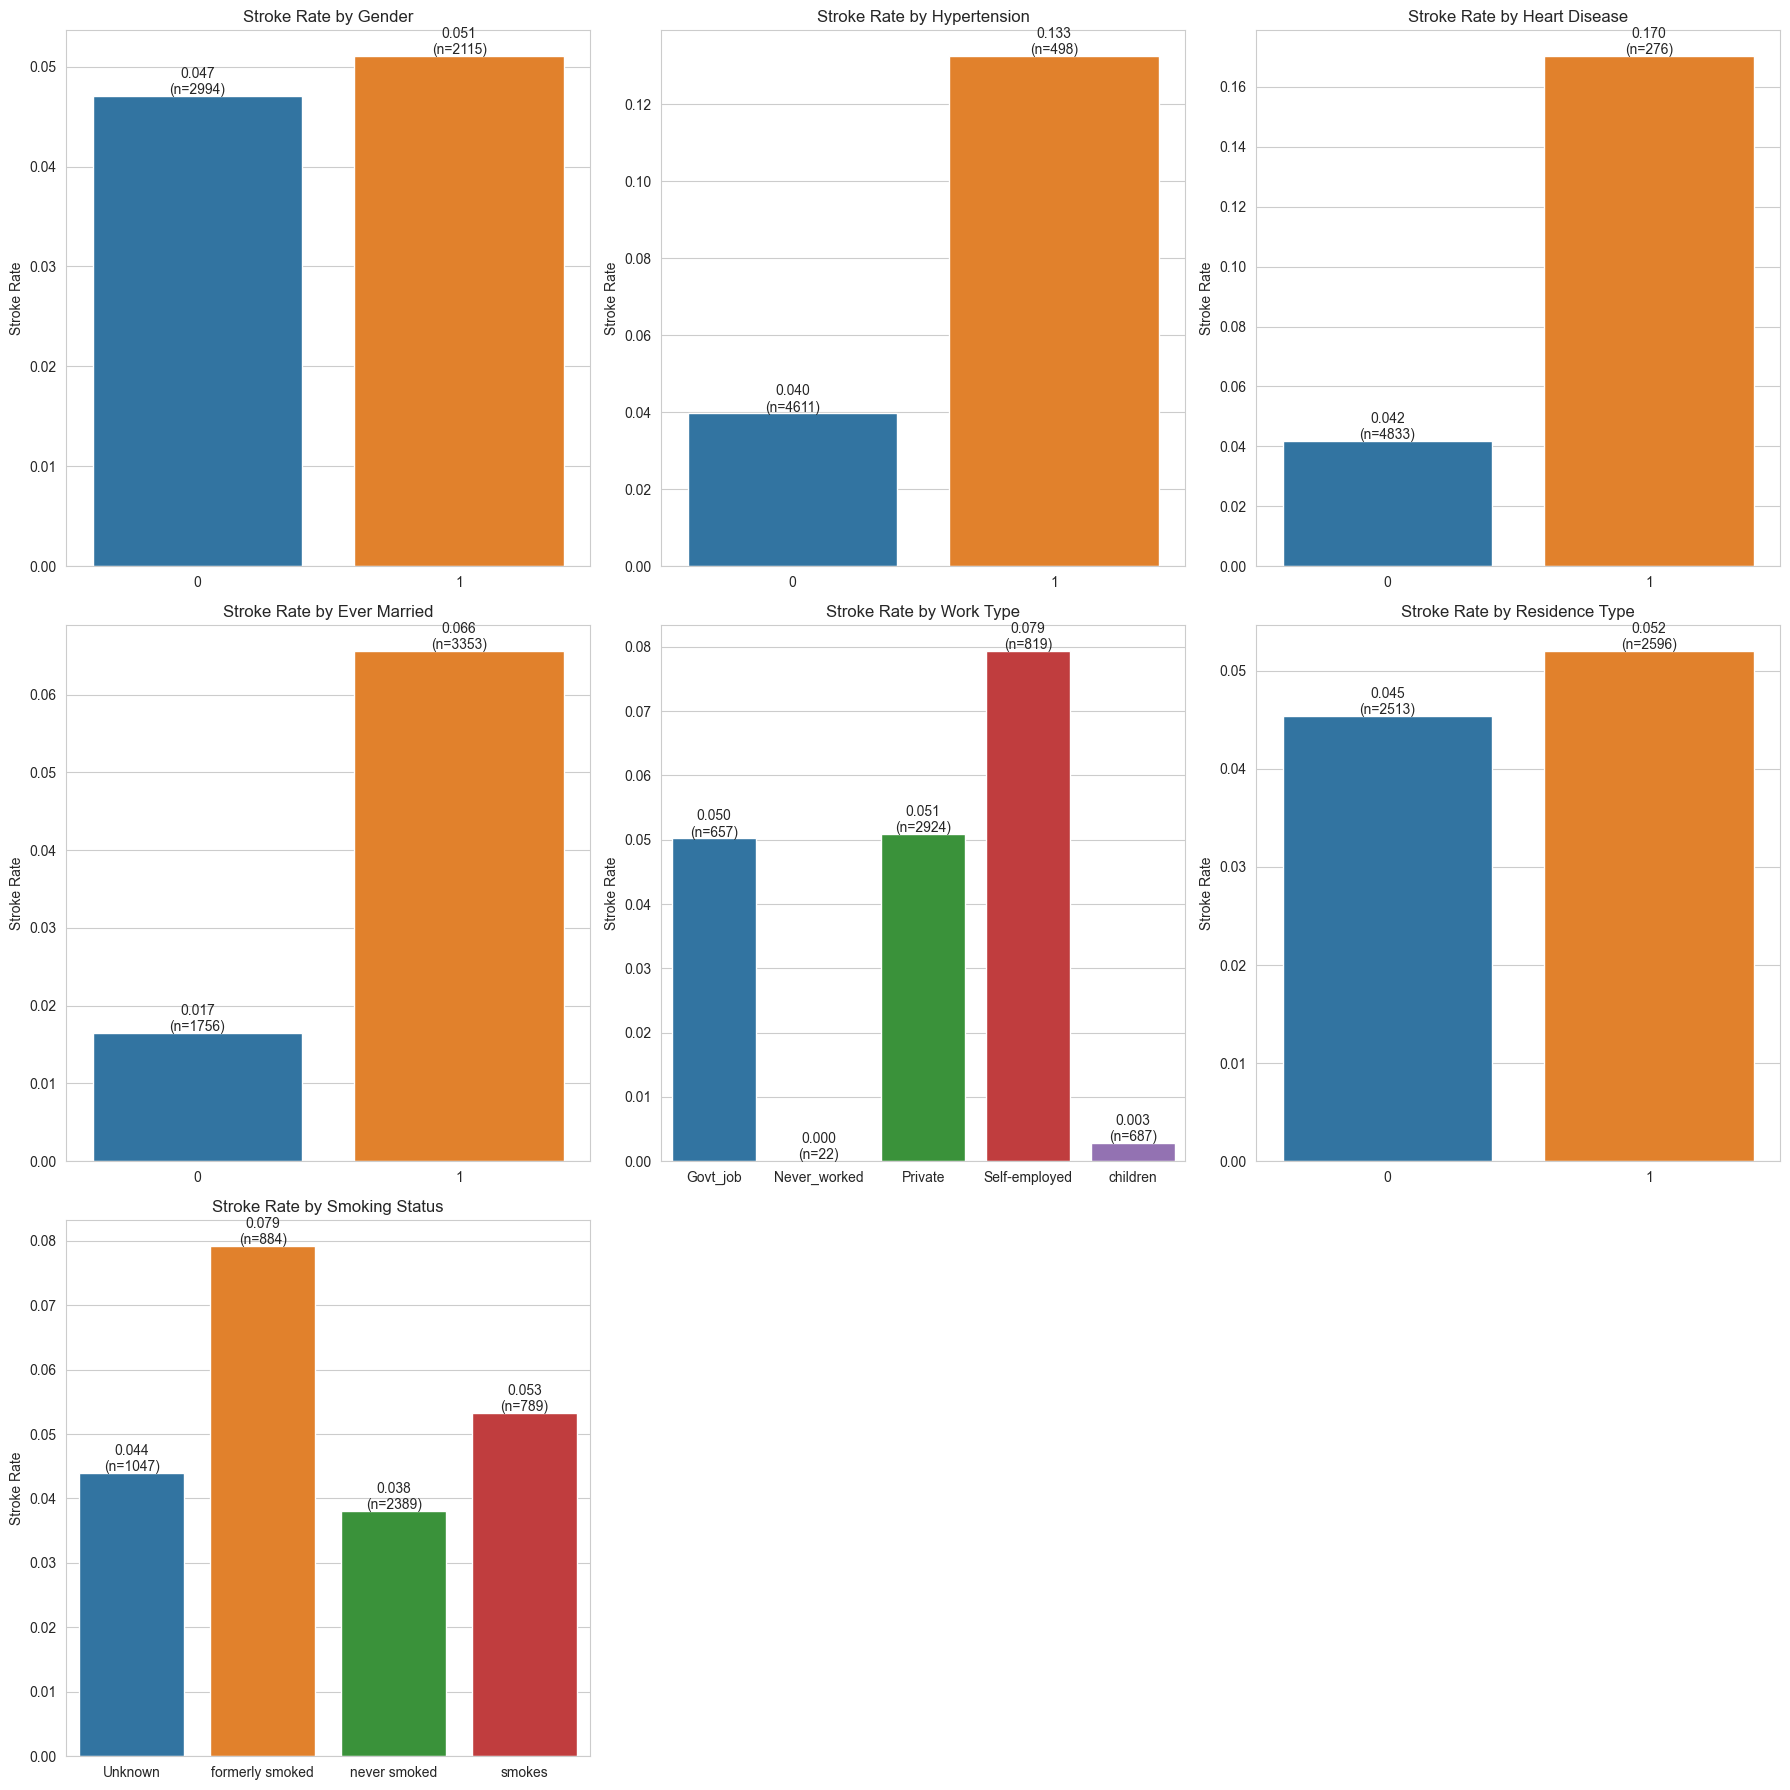

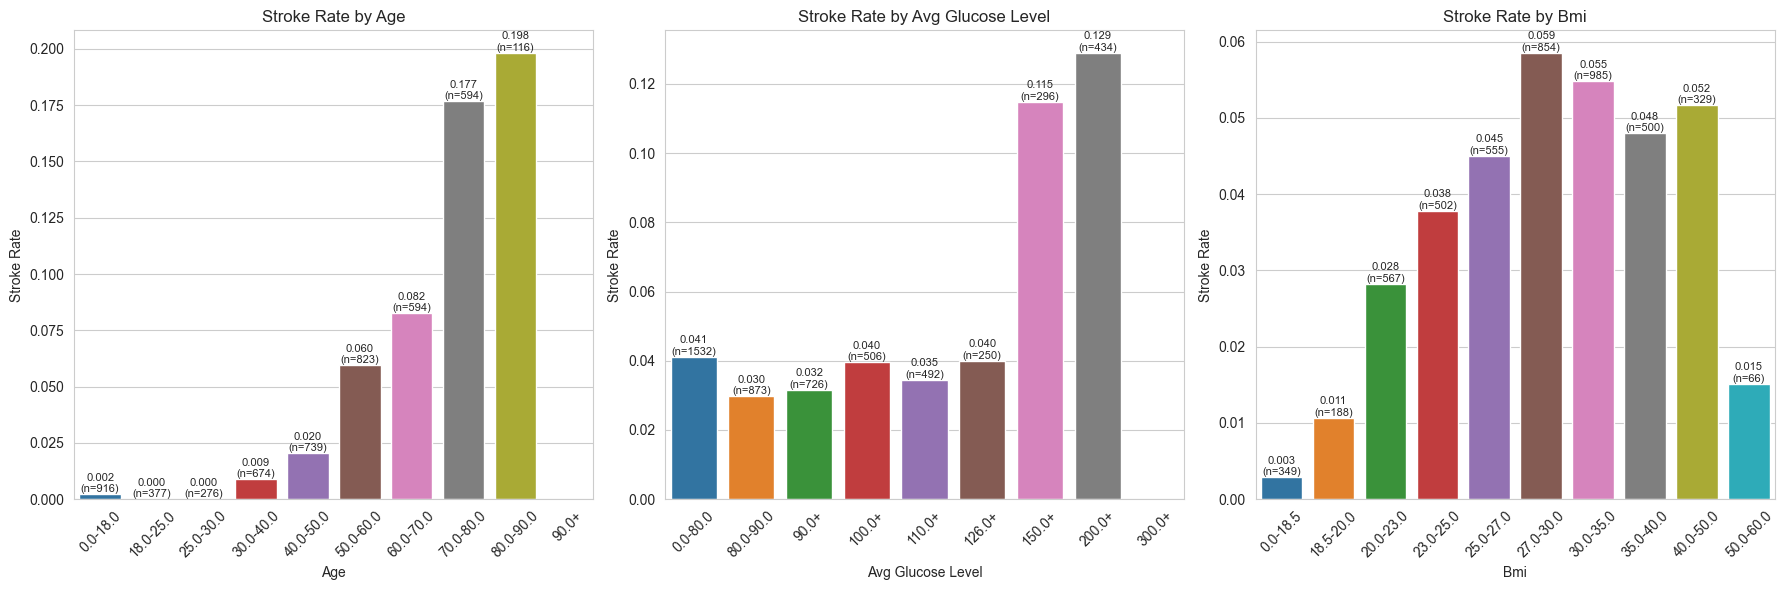

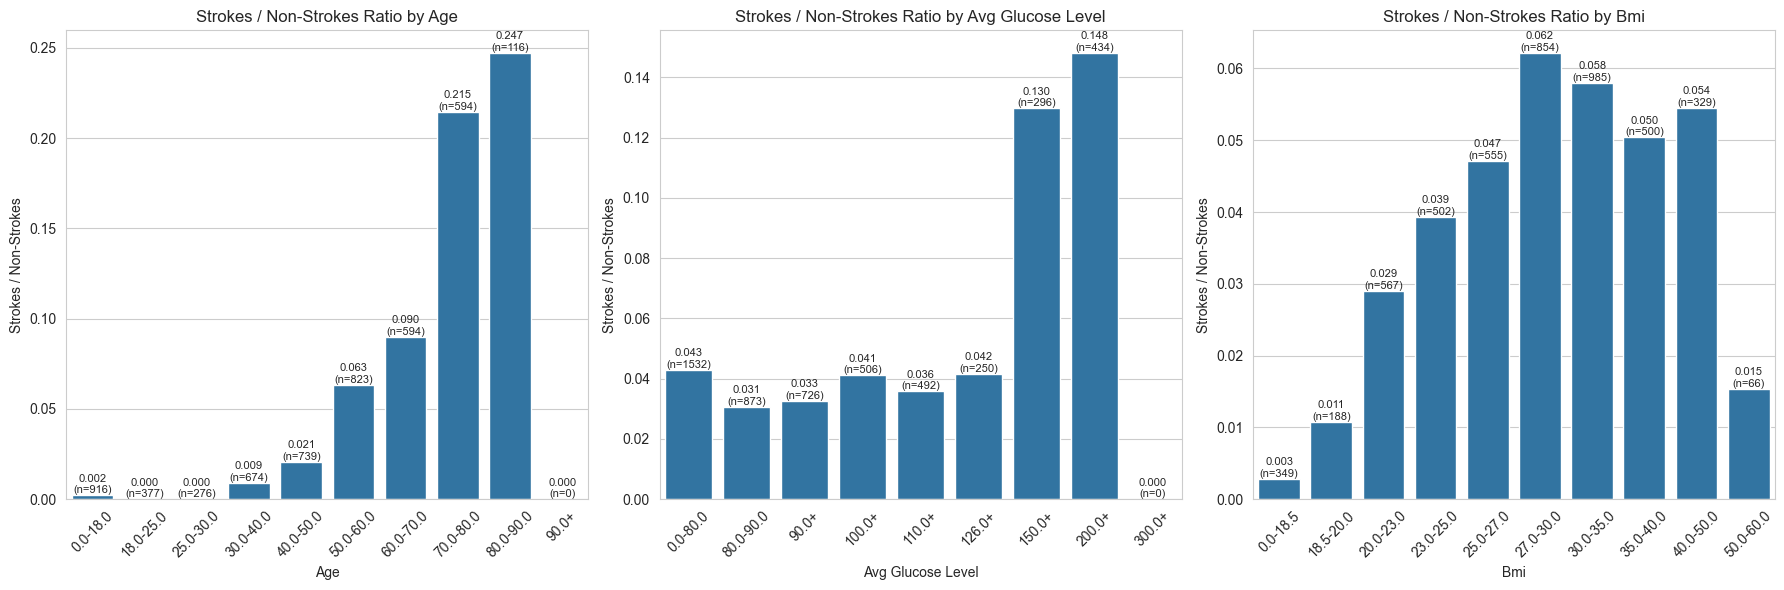


--- Analysis by Gender ---



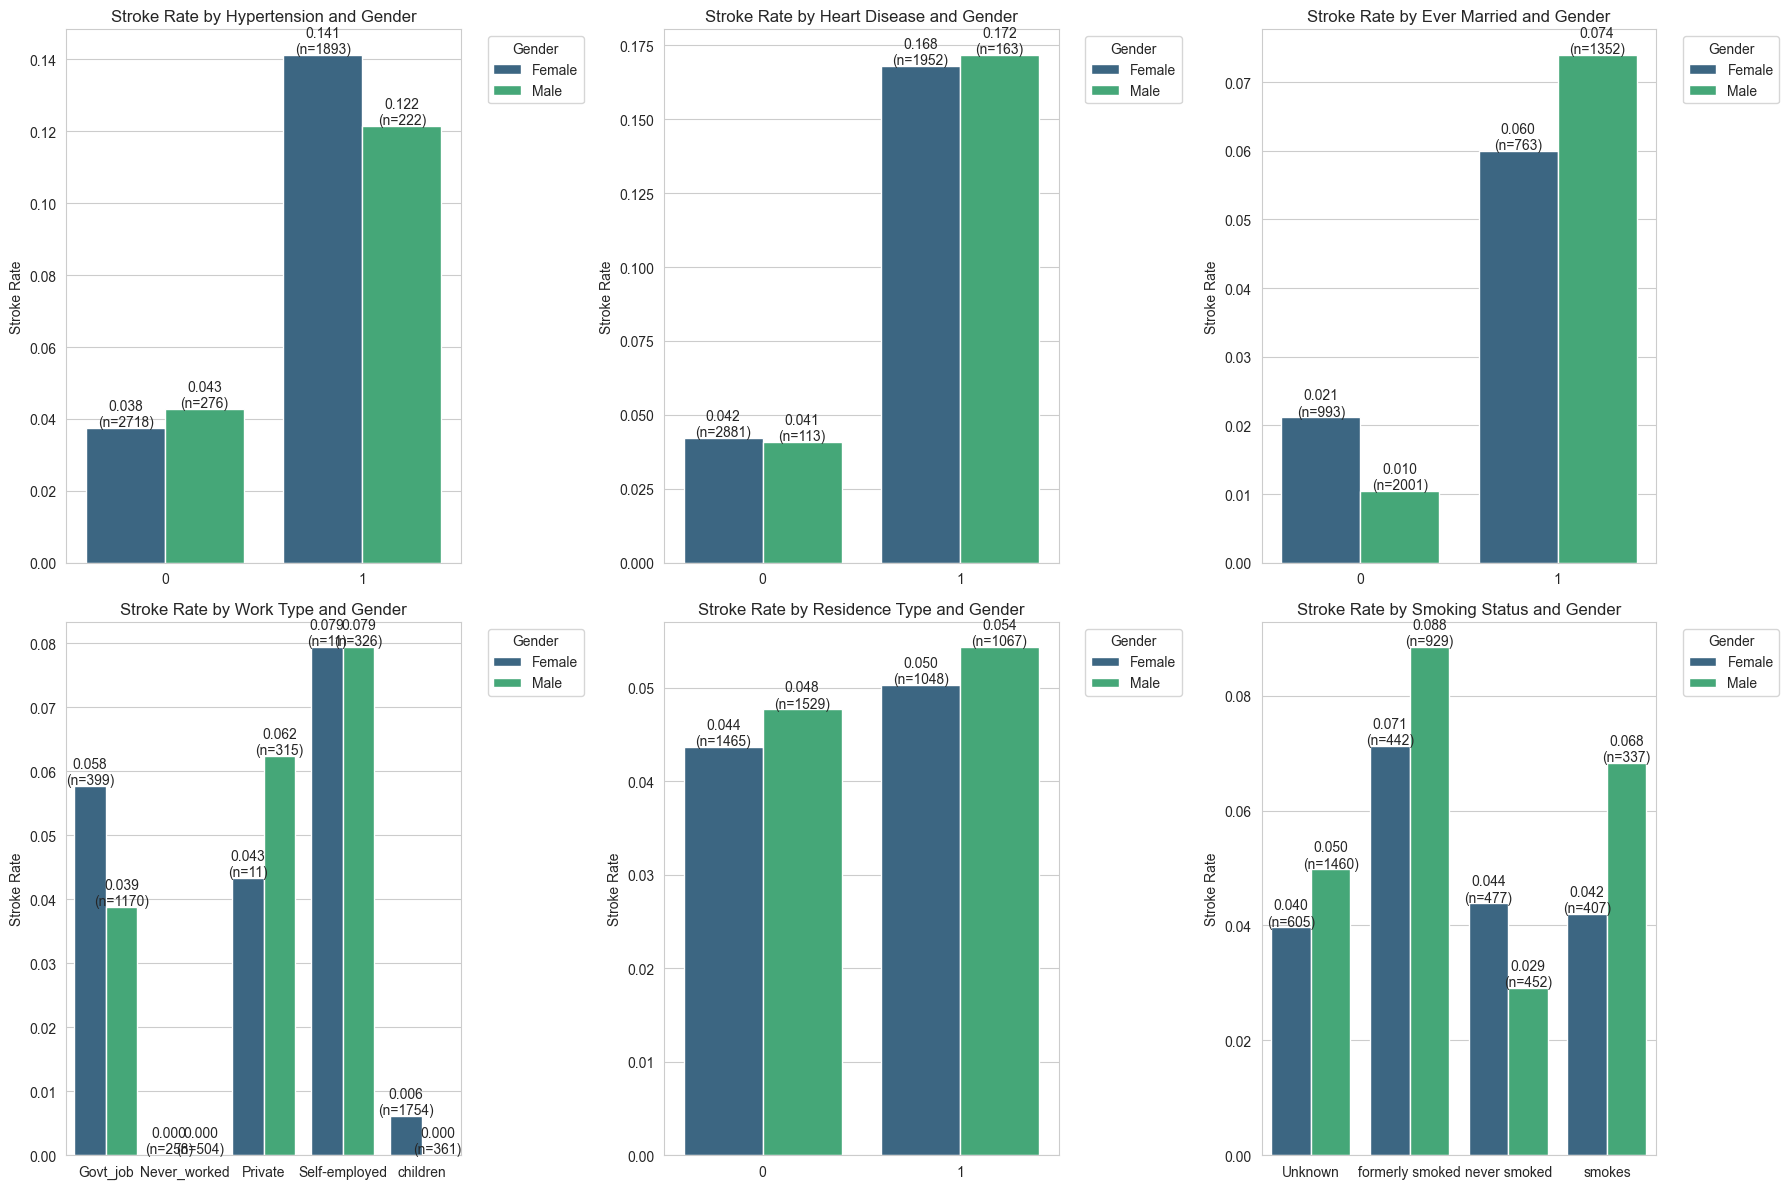

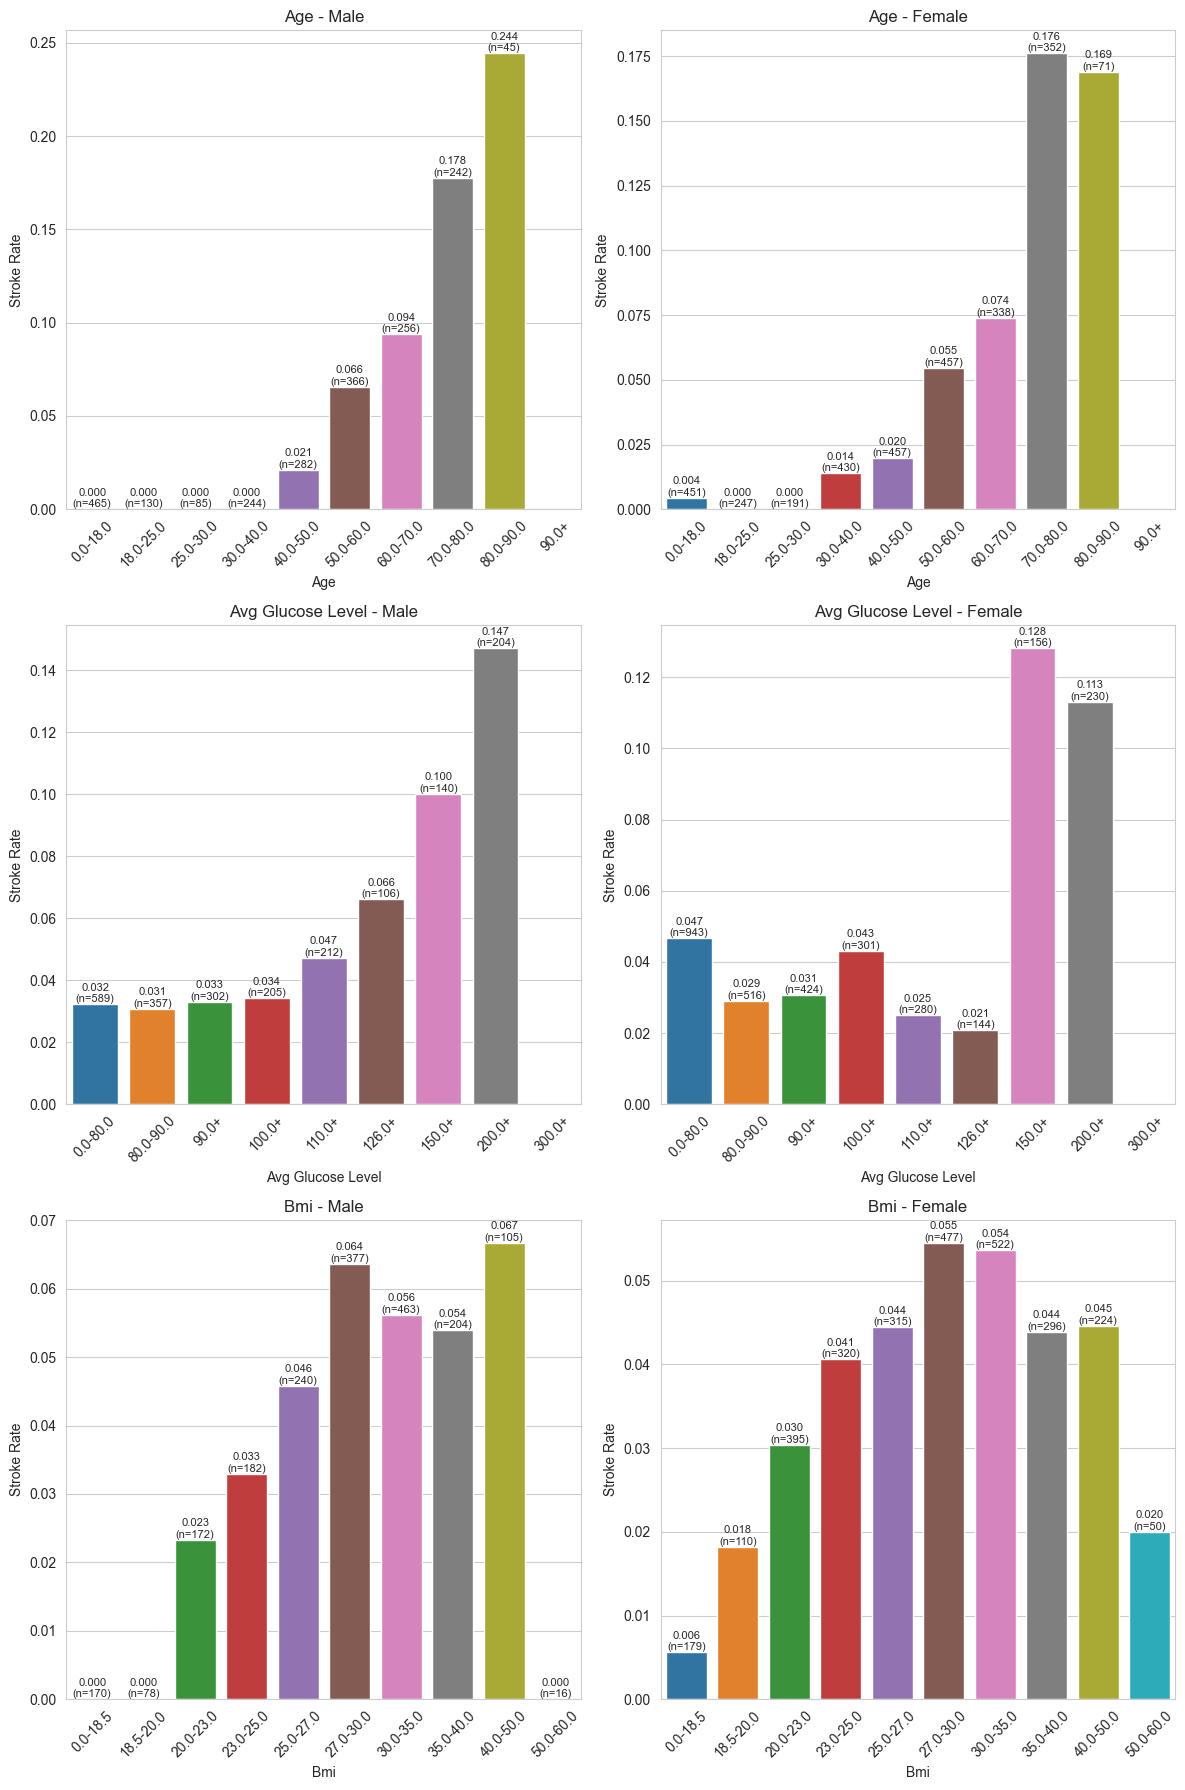

In [191]:
## 3. Exploratory Data Analysis

# Categorical Variables
cat_vars = ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]
plot_categorical_rates(eda_df, cat_vars)

# Numerical Variables
num_vars = ["age", "avg_glucose_level", "bmi"]
bins_age = [0, 18, 25, 30, 40, 50, 60, 70, 80, 90, 100]
bins_glucose = [0, 80, 90, 100, 110, 126, 150, 200, 300, 500]
bins_bmi = [0, 18.5, 20, 23, 25, 27, 30, 35, 40, 50, 60]
bin_dict = {"age": bins_age, "avg_glucose_level": bins_glucose, "bmi": bins_bmi}

plot_numerical_dist(eda_df, num_vars, bin_dict)

# Binned Ratios
plot_binned_ratios(eda_df, num_vars, bin_dict)

# Analysis by Gender
print("\n--- Analysis by Gender ---\n")
cat_vars_gender = ["hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]
plot_categorical_rates_by_gender(eda_df, cat_vars_gender)
plot_numerical_stroke_rates_by_gender(eda_df, num_vars, bin_dict)


### Missing BMI Analysis

Visualising relationship between missing bmi and stroke

NA values in bmi: 201
NA values in age: 0


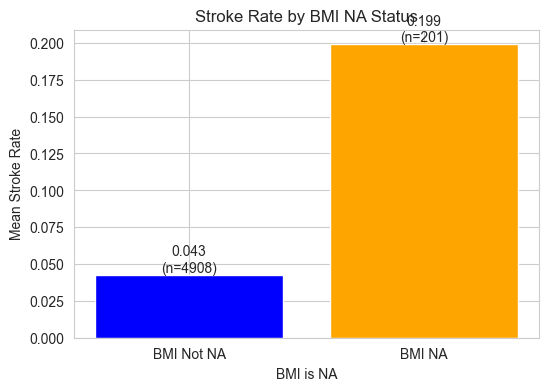

<Figure size 800x500 with 0 Axes>

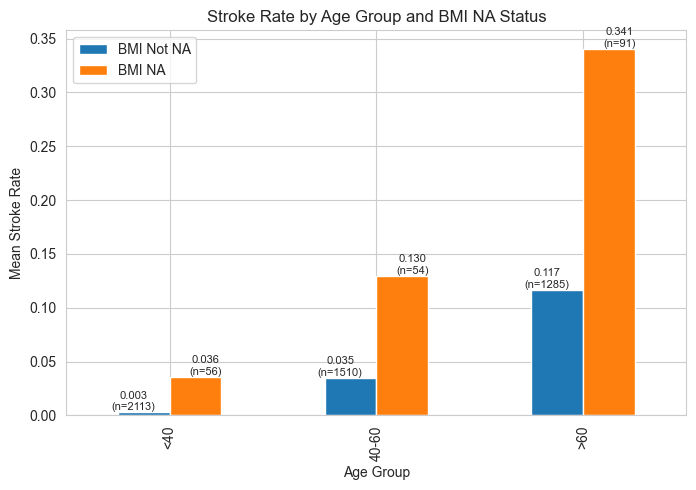

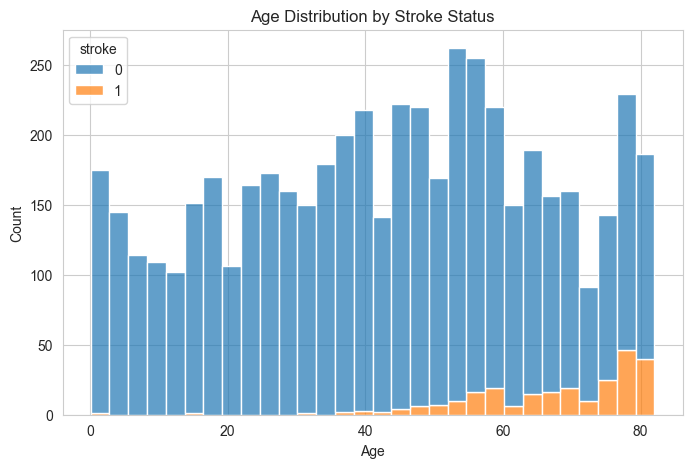

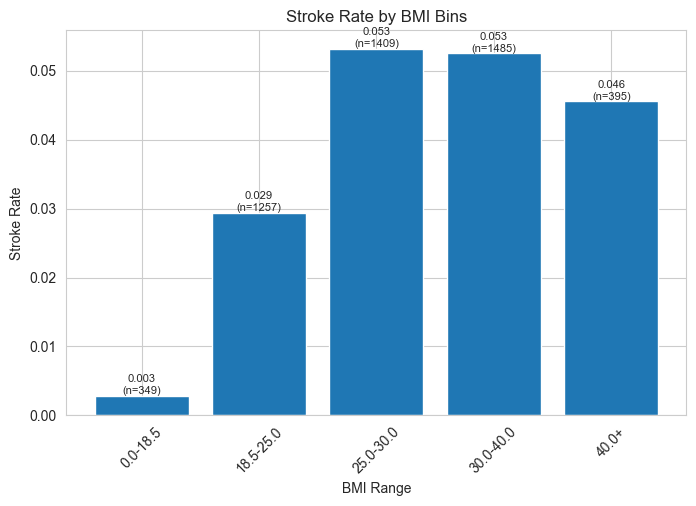

In [192]:
graph_df = stroke_df.copy()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Replace 'N/A' with NaN
graph_df.replace('N/A', pd.NA, inplace=True)

# Convert columns to appropriate types
graph_df['age'] = pd.to_numeric(graph_df['age'], errors='coerce')
graph_df['bmi'] = pd.to_numeric(graph_df['bmi'], errors='coerce')
graph_df['stroke'] = pd.to_numeric(graph_df['stroke'], errors='coerce')

# Check for NA values in bmi and age columns
print("NA values in bmi:", graph_df['bmi'].isna().sum())
print("NA values in age:", graph_df['age'].isna().sum())

# Create bmi_na column
graph_df['bmi_na'] = graph_df['bmi'].isna()

# 1. Bar plot of stroke rate for bmi NA vs not NA
stroke_rate_bmi = graph_df.groupby('bmi_na', observed=False)['stroke'].agg(['mean', 'count'])
plt.figure(figsize=(6, 4))
bars = plt.bar([0, 1], stroke_rate_bmi['mean'], color=['blue', 'orange'])
plt.title('Stroke Rate by BMI NA Status')
plt.xlabel('BMI is NA')
plt.ylabel('Mean Stroke Rate')
plt.xticks([0, 1], ['BMI Not NA', 'BMI NA'], rotation=0)
for bar, mean_val, count in zip(bars, stroke_rate_bmi['mean'], stroke_rate_bmi['count']):
    plt.annotate(f'{mean_val:.3f}\n(n={count})', (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha='center', va='bottom')
plt.show()

# 2. Bar plot of stroke rate by age groups and bmi NA
# Define age groups
bins = [0, 40, 60, 100]
labels = ['<40', '40-60', '>60']
graph_df['age_group'] = pd.cut(graph_df['age'], bins=bins, labels=labels, right=False)

# Group by age_group and bmi_na
stroke_rate_age_bmi = graph_df.groupby(['age_group', 'bmi_na'], observed=False)['stroke'].agg(['mean', 'count']).unstack()

plt.figure(figsize=(8, 5))
ax = stroke_rate_age_bmi['mean'].plot(kind='bar', figsize=(8, 5))
plt.title('Stroke Rate by Age Group and BMI NA Status')
plt.xlabel('Age Group')
plt.ylabel('Mean Stroke Rate')
plt.legend(['BMI Not NA', 'BMI NA'])

# Add n annotations
for i, (idx, row) in enumerate(stroke_rate_age_bmi.iterrows()):
    for j, (col, val) in enumerate(row['mean'].items()):
        count = stroke_rate_age_bmi.loc[idx, ('count', col)]
        height = val
        ax.annotate(f'{height:.3f}\n(n={count})', (i + j*0.35 - 0.175, height), ha='center', va='bottom', fontsize=8)

plt.show()

# 3. Additional graph: Distribution of age for stroke vs no stroke, colored by bmi NA
plt.figure(figsize=(8, 5))
sns.histplot(data=graph_df, x='age', hue='stroke', multiple='stack', bins=30, alpha=0.7)
plt.title('Age Distribution by Stroke Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 4. Stroke rate by BMI bins instead of boxplot
bmi_bins = [0, 18.5, 25, 30, 40, 60]
graph_df['bmi_bin'] = pd.cut(graph_df['bmi'], bins=bmi_bins)
bmi_stroke_rate = graph_df.groupby('bmi_bin', observed=False)['stroke'].agg(['mean', 'count']).reset_index()
bmi_stroke_rate['label'] = bmi_stroke_rate['bmi_bin'].apply(lambda x: f'{x.left:.1f}-{x.right:.1f}' if x.right < 60 else f'{x.left:.1f}+')

plt.figure(figsize=(8, 5))
bars = plt.bar(range(len(bmi_stroke_rate)), bmi_stroke_rate['mean'])
plt.xticks(range(len(bmi_stroke_rate)), bmi_stroke_rate['label'], rotation=45)
plt.title('Stroke Rate by BMI Bins')
plt.xlabel('BMI Range')
plt.ylabel('Stroke Rate')
for bar, mean_val, count in zip(bars, bmi_stroke_rate['mean'], bmi_stroke_rate['count']):
    plt.annotate(f'{mean_val:.3f}\n(n={count})', (bar.get_x() + bar.get_width() / 2, bar.get_height()), ha='center', va='bottom', fontsize=8)
plt.show()


## 4. Example Final Dataset


## New Features Created

### Interaction Features
- **bmi_glucose_interaction**: BMI × average glucose level
- **bmi_age_interaction**: BMI × age
- **glucose_age_interaction**: Average glucose level × age
- **bmi_glucose_age_triple**: BMI × glucose × age
- **bmi_glucose_ratio**: BMI / glucose (0 if glucose = 0)
- **age_adjusted_bmi_glucose**: (BMI × glucose) / age (0 if age = 0)

### Medical Domain Features
- **Age_Squared**: Age squared for non-linear age effects
- **Is_Pediatric**: 1 if age < 18, 0 otherwise
- **Vascular_Score**: Sum of hypertension + heart_disease
- **Vasculature_Stress**: Age × (1 + Vascular_Score)
- **Log_Glucose**: Natural log of (glucose + 1)
- **Diabesity_Flag**: 1 if glucose > 200 AND BMI > 30
- **BMI_Missing_Flag**: 1 if BMI was originally missing
- **Smoker_Hypertensive**: 1 if current smoker AND hypertensive
- **Smoking_History**: 1 if current OR former smoker
- **History_Completeness**: Count of missing values in key fields
- **BMI_Deviation**: Absolute deviation from healthy BMI (22)
- **Premature_Risk_Flag**: 1 if age < 55 with ≥2 risk factors

### Smoking Status Dummies (created during imputation)
- **smoking_never**: 1 if never smoked
- **smoking_former**: 1 if formerly smoked  
- **smoking_current**: 1 if currently smokes


In [193]:
## Demonstrated Processed Dataset

# Load raw data
example_df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values=["N/A", ""])

# Apply initial preprocessing
example_df = example_df[example_df["gender"] != "Other"].copy()
example_df["gender"] = example_df["gender"].map({"Male": 1, "Female": 0})
example_df["ever_married"] = example_df["ever_married"].map({"Yes": 1, "No": 0})
example_df["Residence_type"] = example_df["Residence_type"].map({"Urban": 1, "Rural": 0})
example_df["smoking_status"] = example_df["smoking_status"].fillna("Unknown")
example_df.loc[(example_df['age'] <= 10) & (example_df['smoking_status'] == 'Unknown'), 'smoking_status'] = 'never smoked'
example_df['age'] = example_df['age'].astype(float)
example_df['bmi'] = example_df['bmi'].astype(float)
example_df['stroke'] = example_df['stroke'].astype(int)
example_df['BMI_Missing_Flag'] = example_df['bmi'].isna()

# Encode smoking status
smoking_encoded = example_df['smoking_status'].map({
    'never smoked': 0,
    'formerly smoked': 1,
    'smokes': 2,
    'Unknown': pd.NA
}).astype("Int64")
smoking_encoded = smoking_encoded.where(smoking_encoded != 3, pd.NA)
example_df.insert(example_df.columns.get_loc('smoking_status') + 1, 'smoking_status_encoded', smoking_encoded)

# Create dummy variables for work_type
work_type_dummies = pd.get_dummies(example_df['work_type'], prefix='work_type').astype(int)
example_df = pd.concat([example_df.drop('work_type', axis=1), work_type_dummies], axis=1)
example_df = example_df.drop('id', axis=1)

# Apply imputation and feature engineering
imputer = StrokeDataImputer()
imputed_df = imputer.fit_transform(example_df)
imputed_example_df = create_composite_risk_features(imputed_df)

print("Processed Dataset Shape:", imputed_example_df.shape)
print(list(imputed_example_df.columns))
print("\nFirst 5 rows of Processed Dataset:")
print(imputed_example_df.head())
print("\nSummary Statistics:")
print(imputed_example_df.describe())


Processed Dataset Shape: (5109, 37)
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'smoking_status_encoded', 'stroke', 'BMI_Missing_Flag', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_never', 'smoking_former', 'smoking_current', 'bmi_glucose_interaction', 'bmi_age_interaction', 'glucose_age_interaction', 'bmi_glucose_age_triple', 'bmi_glucose_ratio', 'age_adjusted_bmi_glucose', 'Age_Squared', 'Is_Pediatric', 'Vascular_Score', 'Vasculature_Stress', 'Log_Glucose', 'Diabesity_Flag', 'Smoker_Hypertensive', 'Smoking_History', 'History_Completeness', 'BMI_Deviation', 'Premature_Risk_Flag']

First 5 rows of Processed Dataset:
   gender   age  hypertension  heart_disease  ever_married  Residence_type  avg_glucose_level    bmi  \
0       1  67.0             0              1             1               1             228.69  31.54   

## 5. Model Evaluation

In [ ]:
# Comprehensive Stroke Prediction Model Evaluation Suite
# This code block evaluates multiple ML models with various imbalance handling techniques
# using stratified 5-fold CV and the modular preprocessing pipeline.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score, 
    confusion_matrix, roc_curve, precision_recall_curve, classification_report
)
from sklearn.preprocessing import StandardScaler  # Added for data scaling
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier
import xgboost as xgb
# from preprocess_impute_fold import preprocess_and_impute_fold

# Set random seed for reproducibility
np.random.seed(42)

# Assuming stroke_df is already loaded in the notebook
# stroke_df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values=["N/A", ""])

# Prepare data for CV (raw data before preprocessing)
X = stroke_df.drop('stroke', axis=1)
y = stroke_df['stroke']

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000, solver='saga'),  # Updated solver and max_iter
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss'),
    'Balanced Random Forest': BalancedRandomForestClassifier(random_state=42, n_estimators=100)
}

# Define imbalance handling techniques
imbalance_techniques = {
    'Class Weights': lambda model: model.set_params(class_weight='balanced') if hasattr(model, 'class_weight') else model,
    'Random Oversampling': lambda model: ('oversample', RandomOverSampler(random_state=42)),
    'Balanced Ensemble': lambda model: BalancedBaggingClassifier(
        estimator=model, random_state=42, n_estimators=10
    ),
    'SMOTE': lambda model: ('smote', SMOTE(random_state=42))
}

# Metrics to collect
metrics = ['recall_macro', 'recall_weighted', 'precision_macro', 'precision_weighted', 
           'f1_macro', 'f1_weighted', 'auc_roc', 'recall_stroke_class']

# Initialize results storage
results = {}

# Stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    for technique_name, technique_func in imbalance_techniques.items():
        key = f"{model_name}_{technique_name}"
        results[key] = {metric: [] for metric in metrics}
        
        fold_predictions = []
        fold_probabilities = []
        fold_y_true = []
        
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            # Create train and test DataFrames with target column
            train_df = pd.concat([X.iloc[train_idx], y.iloc[train_idx]], axis=1)
            test_df = pd.concat([X.iloc[test_idx], y.iloc[test_idx]], axis=1)
            
            # Apply preprocessing and imputation using the modular function
            X_train_processed, X_test_processed = preprocess_and_impute_fold(train_df, test_df)
            
            # Separate features and target
            y_train_processed = X_train_processed['stroke']
            y_test_processed = X_test_processed['stroke']
            X_train_processed = X_train_processed.drop('stroke', axis=1)
            X_test_processed = X_test_processed.drop('stroke', axis=1)
            
            # Keep only numerical columns (drop any remaining string columns)
            X_train_processed = X_train_processed.select_dtypes(include=[np.number])
            X_test_processed = X_test_processed.select_dtypes(include=[np.number])
            
            # Fill NaN values and drop columns that are still all NaN
            X_train_processed = X_train_processed.fillna(X_train_processed.mean())
            X_test_processed = X_test_processed.fillna(X_train_processed.mean())
            X_train_processed = X_train_processed.dropna(axis=1, how='all')
            X_test_processed = X_test_processed[X_train_processed.columns]
            
            # Apply data scaling
            scaler = StandardScaler()
            X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_processed), columns=X_train_processed.columns, index=X_train_processed.index)
            X_test_scaled = pd.DataFrame(scaler.transform(X_test_processed), columns=X_test_processed.columns, index=X_test_processed.index)
            
            # Apply imbalance handling
            if technique_name == 'Class Weights':
                model_copy = technique_func(model.__class__(**model.get_params()))
                X_train_resampled, y_train_resampled = X_train_scaled, y_train_processed
            elif technique_name in ['Random Oversampling', 'SMOTE']:
                sampler_name, sampler = technique_func(model)
                X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_scaled, y_train_processed)
                model_copy = model
            elif technique_name == 'Balanced Ensemble':
                model_copy = technique_func(model)
                X_train_resampled, y_train_resampled = X_train_scaled, y_train_processed
            else:
                model_copy = model
                X_train_resampled, y_train_resampled = X_train_scaled, y_train_processed
            
            # Fit model
            model_copy.fit(X_train_resampled, y_train_resampled)
            
            # Predict
            y_pred = model_copy.predict(X_test_scaled)
            y_proba = model_copy.predict_proba(X_test_scaled)[:, 1] if hasattr(model_copy, 'predict_proba') else None
            
            # Collect predictions for later plotting
            fold_predictions.extend(y_pred)
            if y_proba is not None:
                fold_probabilities.extend(y_proba)
            fold_y_true.extend(y_test_processed)
            
            # Calculate metrics with error handling for division by zero
            try:
                results[key]['recall_macro'].append(recall_score(y_test_processed, y_pred, average='macro'))
            except ZeroDivisionError:
                results[key]['recall_macro'].append(0.0)
            try:
                results[key]['recall_weighted'].append(recall_score(y_test_processed, y_pred, average='weighted'))
            except ZeroDivisionError:
                results[key]['recall_weighted'].append(0.0)
            try:
                results[key]['precision_macro'].append(precision_score(y_test_processed, y_pred, average='macro'))
            except ZeroDivisionError:
                results[key]['precision_macro'].append(0.0)
            try:
                results[key]['precision_weighted'].append(precision_score(y_test_processed, y_pred, average='weighted'))
            except ZeroDivisionError:
                results[key]['precision_weighted'].append(0.0)
            try:
                results[key]['f1_macro'].append(f1_score(y_test_processed, y_pred, average='macro'))
            except ZeroDivisionError:
                results[key]['f1_macro'].append(0.0)
            try:
                results[key]['f1_weighted'].append(f1_score(y_test_processed, y_pred, average='weighted'))
            except ZeroDivisionError:
                results[key]['f1_weighted'].append(0.0)
            if y_proba is not None:
                try:
                    results[key]['auc_roc'].append(roc_auc_score(y_test_processed, y_proba))
                except ValueError:
                    results[key]['auc_roc'].append(np.nan)
            try:
                results[key]['recall_stroke_class'].append(recall_score(y_test_processed, y_pred, pos_label=1))
            except ZeroDivisionError:
                results[key]['recall_stroke_class'].append(0.0)
        
        # Average metrics across folds
        for metric in metrics:
            if metric == 'auc_roc' and not fold_probabilities:
                results[key][metric] = np.nan
            else:
                results[key][metric] = np.mean(results[key][metric])
        
        # Store fold-level data for plotting
        results[key]['fold_predictions'] = fold_predictions
        results[key]['fold_probabilities'] = fold_probabilities if fold_probabilities else None
        results[key]['fold_y_true'] = fold_y_true

# Convert results to DataFrame for analysis
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.reset_index().rename(columns={'index': 'model_technique'})

# Find best model based on recall for stroke class
best_model = results_df.loc[results_df['recall_stroke_class'].idxmax()]

print("=== MODEL EVALUATION RESULTS ===")
print(f"\nBest Model (based on Recall for Stroke Class): {best_model['model_technique']}")
print(f"Recall for Stroke Class: {best_model['recall_stroke_class']:.4f}")
print(f"AUC-ROC: {best_model['auc_roc']:.4f}")

# Display top 5 models by recall for stroke class
print("\nTop 5 Models by Recall for Stroke Class:")
top_5 = results_df.nlargest(5, 'recall_stroke_class')[['model_technique', 'recall_stroke_class', 'auc_roc', 'f1_macro']]
print(top_5.to_string(index=False))

# Hyperparameters used (documented)
hyperparameters = {
    'Logistic Regression': {'max_iter': 2000, 'solver': 'saga', 'random_state': 42},  # Updated
    'Random Forest': {'n_estimators': 100, 'random_state': 42},
    'XGBoost': {'n_estimators': 100, 'eval_metric': 'logloss', 'random_state': 42},
    'Balanced Random Forest': {'n_estimators': 100, 'random_state': 42},
    'SMOTE': {'random_state': 42},
    'Random Oversampling': {'random_state': 42},
    'Balanced Ensemble': {'n_estimators': 10, 'random_state': 42}
}

print("\n=== HYPERPARAMETERS USED ===")
for model, params in hyperparameters.items():
    print(f"{model}: {params}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ROC Curves for top 3 models
for i, (_, row) in enumerate(top_5.head(3).iterrows()):
    key = row['model_technique']
    if results[key]['fold_probabilities'] is not None:
        fpr, tpr, _ = roc_curve(results[key]['fold_y_true'], results[key]['fold_probabilities'])
        axes[0, 0].plot(fpr, tpr, label=f"{key} (AUC = {row['auc_roc']:.3f})")

axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curves - Top 3 Models')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Precision-Recall Curves for top 3 models
for i, (_, row) in enumerate(top_5.head(3).iterrows()):
    key = row['model_technique']
    if results[key]['fold_probabilities'] is not None:
        precision, recall, _ = precision_recall_curve(results[key]['fold_y_true'], results[key]['fold_probabilities'])
        axes[0, 1].plot(recall, precision, label=f"{key}")

axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curves - Top 3 Models')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Feature Importance for Random Forest (if available)
rf_key = [k for k in results.keys() if 'Random Forest_Class Weights' in k][0]
if hasattr(models['Random Forest'], 'feature_importances_'):
    # Retrain on full processed data for feature importance
    full_df = pd.concat([X, y], axis=1)
    X_full_processed, _ = preprocess_and_impute_fold(full_df, full_df)
    X_full_processed = X_full_processed.drop('stroke', axis=1)
    X_full_processed = X_full_processed.select_dtypes(include=[np.number])
    X_full_processed = X_full_processed.fillna(X_full_processed.mean())
    X_full_processed = X_full_processed.dropna(axis=1, how='all')
    scaler_full = StandardScaler()  # Added scaling for consistency
    X_full_scaled = pd.DataFrame(scaler_full.fit_transform(X_full_processed), columns=X_full_processed.columns, index=X_full_processed.index)
    rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
    rf_model.fit(X_full_scaled, y)
    
    feature_importance = pd.DataFrame({
        'feature': X_full_processed.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    
    sns.barplot(data=feature_importance, x='importance', y='feature', ax=axes[1, 0])
    axes[1, 0].set_title('Top 10 Feature Importances (Random Forest)')
    axes[1, 0].set_xlabel('Importance')

# Confusion Matrix for best model
cm = confusion_matrix(results[best_model['model_technique']]['fold_y_true'], 
                     results[best_model['model_technique']]['fold_predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title(f'Confusion Matrix - {best_model["model_technique"]}')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Summary comparison table
print("\n=== SUMMARY COMPARISON TABLE ===")
summary_cols = ['model_technique', 'recall_stroke_class', 'auc_roc', 'f1_macro', 'precision_macro', 'recall_macro']
print(results_df[summary_cols].sort_values('recall_stroke_class', ascending=False).to_string(index=False))


## 6. Penalized Logistic Regression with Elastic Net

In [ ]:
# Penalized Logistic Regression with Elastic Net Grid Search and Class Weighting
# This code block performs grid search on Elastic Net Logistic Regression with class weighting
# and displays the best parameters in a grid, plus confusion matrix.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
# #from preprocess_impute_fold import preprocess_and_impute_fold

# Set random seed for reproducibility
np.random.seed(42)

# Assuming stroke_df is already loaded in the notebook
# stroke_df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values=["N/A", ""])

# Prepare data for CV (raw data before preprocessing)
X = stroke_df.drop('stroke', axis=1)
y = stroke_df['stroke']

# Stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Elastic Net Logistic Regression Grid Search with Class Weighting
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  # Inverse of alpha
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    'class_weight': ['balanced', None]
}

elastic_net_lr = LogisticRegression(
    penalty='elasticnet', 
    solver='saga', 
    random_state=42, 
    max_iter=10000
)

grid_search = GridSearchCV(
    elastic_net_lr, 
    param_grid, 
    cv=skf, 
    scoring='recall', 
    n_jobs=-1
)

# Preprocess data
full_df = pd.concat([X, y], axis=1)
X_full_processed, _ = preprocess_and_impute_fold(full_df, full_df)
X_full_processed = X_full_processed.drop('stroke', axis=1)
X_full_processed = X_full_processed.select_dtypes(include=[np.number])
X_full_processed = X_full_processed.fillna(X_full_processed.mean())
X_full_processed = X_full_processed.dropna(axis=1, how='all')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full_processed)

grid_search.fit(X_scaled, y)

print("=== ELASTIC NET LOGISTIC REGRESSION GRID SEARCH WITH CLASS WEIGHTING ===")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score (recall): {grid_search.best_score_:.4f}")

# Display grid of mean test scores (for balanced class_weight)
results_df = pd.DataFrame(grid_search.cv_results_)
balanced_results = results_df[results_df['param_class_weight'] == 'balanced']
pivot_table = balanced_results.pivot(index='param_l1_ratio', columns='param_C', values='mean_test_score')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.3f')
plt.title('Grid Search CV Scores (Recall) for Elastic Net LR with Balanced Class Weights')
plt.xlabel('C (Inverse Alpha)')
plt.ylabel('L1 Ratio')
plt.show()

# Evaluate best model on CV and collect predictions for confusion matrix
best_lr = grid_search.best_estimator_
elastic_net_results = {'recall_stroke': [], 'auc_roc': []}
all_y_true = []
all_y_pred = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    train_df = pd.concat([X.iloc[train_idx], y.iloc[train_idx]], axis=1)
    test_df = pd.concat([X.iloc[test_idx], y.iloc[test_idx]], axis=1)
    
    X_train_processed, X_test_processed = preprocess_and_impute_fold(train_df, test_df)
    y_train_processed = X_train_processed['stroke']
    y_test_processed = X_test_processed['stroke']
    X_train_processed = X_train_processed.drop('stroke', axis=1)
    X_test_processed = X_test_processed.drop('stroke', axis=1)
    
    X_train_processed = X_train_processed.select_dtypes(include=[np.number])
    X_test_processed = X_test_processed.select_dtypes(include=[np.number])
    X_train_processed = X_train_processed.fillna(X_train_processed.mean())
    X_test_processed = X_test_processed.fillna(X_train_processed.mean())
    X_train_processed = X_train_processed.dropna(axis=1, how='all')
    X_test_processed = X_test_processed[X_train_processed.columns]
    
    scaler_fold = StandardScaler()
    X_train_scaled = scaler_fold.fit_transform(X_train_processed)
    X_test_scaled = scaler_fold.transform(X_test_processed)
    
    best_lr_fold = LogisticRegression(
        penalty='elasticnet', 
        solver='saga', 
        **{k: v for k, v in grid_search.best_params_.items() if k != 'class_weight'},  # Remove class_weight if None
        class_weight=grid_search.best_params_['class_weight'],
        random_state=42, 
        max_iter=10000
    )
    best_lr_fold.fit(X_train_scaled, y_train_processed)
    
    y_pred = best_lr_fold.predict(X_test_scaled)
    y_pred_proba = best_lr_fold.predict_proba(X_test_scaled)[:, 1]
    
    elastic_net_results['recall_stroke'].append(recall_score(y_test_processed, y_pred, pos_label=1))
    elastic_net_results['auc_roc'].append(roc_auc_score(y_test_processed, y_pred_proba))
    
    all_y_true.extend(y_test_processed)
    all_y_pred.extend(y_pred)

print(f"\nBest Elastic Net LR CV Results:")
print(f"Average Recall for Stroke Class: {np.mean(elastic_net_results['recall_stroke']):.4f}")
print(f"Average AUC-ROC: {np.mean(elastic_net_results['auc_roc']):.4f}")

# Confusion Matrix for Best Model
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix - Best Elastic Net Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 7. Neural Network Implementation

In [ ]:
# Neural Network with PyTorch (MPS Compatible) and Class Weighting
# This code block implements a neural network using PyTorch with MPS support,
# class weighting for imbalance, and progress trackers.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
# #from preprocess_impute_fold import preprocess_and_impute_fold
from tqdm import tqdm  # For progress bars
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check for MPS availability
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming stroke_df is already loaded in the notebook
# stroke_df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values=["N/A", ""])

# Prepare data
X = stroke_df.drop('stroke', axis=1)
y = stroke_df['stroke']

# Define Neural Network Model (output logits, no sigmoid)
class StrokeNN(nn.Module):
    def __init__(self, input_size):
        super(StrokeNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # Output logits
        return x

# Training function with progress tracker (print every 10 epochs)
def train_model(model, train_loader, criterion, optimizer, num_epochs=100):
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels.float())
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=f"{epoch_loss/len(train_loader):.4f}")
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {epoch_loss/len(train_loader):.4f}")

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs.squeeze())  # Apply sigmoid for probabilities
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
nn_results = {'recall_stroke': [], 'auc_roc': []}
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/5")
    train_df = pd.concat([X.iloc[train_idx], y.iloc[train_idx]], axis=1)
    test_df = pd.concat([X.iloc[test_idx], y.iloc[test_idx]], axis=1)
    
    X_train_processed, X_test_processed = preprocess_and_impute_fold(train_df, test_df)
    y_train_processed = X_train_processed['stroke']
    y_test_processed = X_test_processed['stroke']
    X_train_processed = X_train_processed.drop('stroke', axis=1)
    X_test_processed = X_test_processed.drop('stroke', axis=1)
    
    X_train_processed = X_train_processed.select_dtypes(include=[np.number])
    X_test_processed = X_test_processed.select_dtypes(include=[np.number])
    X_train_processed = X_train_processed.fillna(X_train_processed.mean())
    X_test_processed = X_test_processed.fillna(X_train_processed.mean())
    X_train_processed = X_train_processed.dropna(axis=1, how='all')
    X_test_processed = X_test_processed[X_train_processed.columns]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_processed)
    X_test_scaled = scaler.transform(X_test_processed)
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    y_train_tensor = torch.FloatTensor(y_train_processed.values)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    y_test_tensor = torch.FloatTensor(y_test_processed.values)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Initialize model
    input_size = X_train_scaled.shape[1]
    model = StrokeNN(input_size).to(device)
    
    # Class weighting
    num_pos = y_train_processed.sum()
    num_neg = len(y_train_processed) - num_pos
    pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
    
    # Loss and optimizer
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
    
    # Train
    train_model(model, train_loader, criterion, optimizer, num_epochs=100)
    
    # Evaluate
    y_pred, y_true, y_prob = evaluate_model(model, test_loader)
    
    nn_results['recall_stroke'].append(recall_score(y_true, y_pred, pos_label=1))
    nn_results['auc_roc'].append(roc_auc_score(y_true, y_prob))
    
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

print("=== NEURAL NETWORK CV RESULTS ===")
print(f"Average Recall for Stroke Class: {np.mean(nn_results['recall_stroke']):.4f}")
print(f"Average AUC-ROC: {np.mean(nn_results['auc_roc']):.4f}")

# Overall metrics
overall_recall_stroke = recall_score(all_y_true, all_y_pred, pos_label=1)
overall_precision_stroke = precision_score(all_y_true, all_y_pred, pos_label=1)
overall_f1_stroke = f1_score(all_y_true, all_y_pred, pos_label=1)
overall_auc_roc = roc_auc_score(all_y_true, all_y_prob)

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("=== OVERALL METRICS ===")
print(f"Recall for Stroke Class: {overall_recall_stroke:.4f}")
print(f"Precision for Stroke Class: {overall_precision_stroke:.4f}")
print(f"F1 for Stroke Class: {overall_f1_stroke:.4f}")
print(f"AUC-ROC: {overall_auc_roc:.4f}")


## 8. Improved Stacking Ensemble Method

In [ ]:
# Improved Stacking Ensemble Method with Class Weighting
# This code block implements a stacking ensemble with meta-learner for better performance.

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, roc_auc_score, precision_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
# #from preprocess_impute_fold import preprocess_and_impute_fold
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Assuming stroke_df is already loaded in the notebook
# stroke_df = pd.read_csv("healthcare-dataset-stroke-data.csv", na_values=["N/A", ""])

# Prepare data
X = stroke_df.drop('stroke', axis=1)
y = stroke_df['stroke']

# Define base models with better tuning
base_models = [
    ('elastic_net_lr', LogisticRegression(
        penalty='elasticnet', 
        solver='saga', 
        C=1.0,  # Increased
        l1_ratio=0.1,  # More L1
        class_weight='balanced',
        random_state=42, 
        max_iter=10000
    )),
    ('random_forest', RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced',
        max_depth=None,  # Allow deeper
        min_samples_split=10,  # Added
        random_state=42
    )),
    ('xgboost', xgb.XGBClassifier(
        n_estimators=100, 
        scale_pos_weight=len(y) / y.sum(),
        max_depth=4,  # Shallower
        learning_rate=0.1,  # Added
        random_state=42,
        eval_metric='logloss'
    ))
]

# Meta-learner
meta_model = LogisticRegression(class_weight='balanced', random_state=42)

# Create stacking ensemble
stacking_ensemble = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,  # Internal CV for stacking
    stack_method='predict_proba'
)

# Stratified 5-fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ensemble_results = {'recall_stroke': [], 'auc_roc': []}
all_y_true = []
all_y_pred = []
all_y_prob = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold+1}/5")
    train_df = pd.concat([X.iloc[train_idx], y.iloc[train_idx]], axis=1)
    test_df = pd.concat([X.iloc[test_idx], y.iloc[test_idx]], axis=1)
    
    X_train_processed, X_test_processed = preprocess_and_impute_fold(train_df, test_df)
    y_train_processed = X_train_processed['stroke']
    y_test_processed = X_test_processed['stroke']
    X_train_processed = X_train_processed.drop('stroke', axis=1)
    X_test_processed = X_test_processed.drop('stroke', axis=1)
    
    X_train_processed = X_train_processed.select_dtypes(include=[np.number])
    X_test_processed = X_test_processed.select_dtypes(include=[np.number])
    X_train_processed = X_train_processed.fillna(X_train_processed.mean())
    X_test_processed = X_test_processed.fillna(X_train_processed.mean())
    X_train_processed = X_train_processed.dropna(axis=1, how='all')
    X_test_processed = X_test_processed[X_train_processed.columns]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_processed)
    X_test_scaled = scaler.transform(X_test_processed)
    
    # Fit stacking ensemble
    stacking_ensemble.fit(X_train_scaled, y_train_processed)
    
    # Predict
    y_pred = stacking_ensemble.predict(X_test_scaled)
    y_pred_proba = stacking_ensemble.predict_proba(X_test_scaled)[:, 1]
    
    ensemble_results['recall_stroke'].append(recall_score(y_test_processed, y_pred, pos_label=1))
    ensemble_results['auc_roc'].append(roc_auc_score(y_test_processed, y_pred_proba))
    
    all_y_true.extend(y_test_processed)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_pred_proba)

print("=== IMPROVED STACKING ENSEMBLE CV RESULTS ===")
print(f"Average Recall for Stroke Class: {np.mean(ensemble_results['recall_stroke']):.4f}")
print(f"Average AUC-ROC: {np.mean(ensemble_results['auc_roc']):.4f}")

# Overall metrics
overall_recall_stroke = recall_score(all_y_true, all_y_pred, pos_label=1)
overall_precision_stroke = precision_score(all_y_true, all_y_pred, pos_label=1)
overall_f1_stroke = f1_score(all_y_true, all_y_pred, pos_label=1)
overall_auc_roc = roc_auc_score(all_y_true, all_y_prob)

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title('Confusion Matrix - Improved Stacking Ensemble')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("=== OVERALL METRICS ===")
print(f"Recall for Stroke Class: {overall_recall_stroke:.4f}")
print(f"Precision for Stroke Class: {overall_precision_stroke:.4f}")
print(f"F1 for Stroke Class: {overall_f1_stroke:.4f}")
print(f"AUC-ROC: {overall_auc_roc:.4f}")
